# LAB 7: Deep Learning
##  `Dataset` & `DataLoader` on a Toy Set

A `DataLoader` produces batches. But where does it get its data? From a **`Dataset`**.

This notebook builds that machinery and demonstrates it on a dataset small enough to print in full — **10 samples, 2 features**. Everything here is runnable and complete; you are meant to read it, run it, and change the numbers.

**By the end you will be able to:**
- Write a custom `Dataset` with `__init__`, `__len__` and `__getitem__`.
- Explain what a `DataLoader` does with those three methods.
- Predict how many batches a given `batch_size` and `drop_last` produce, and check yourself.
- Say exactly where the batch dimension is created.

> Part 2 (`Lab7_Exercise_Breast_Cancer_Pipeline.ipynb`) is the practice exercise — you rebuild this whole pipeline on a real 569-sample medical dataset.

## 1. The two abstractions

| | Job |
|---|---|
| **`Dataset`** | Knows what the data *is*. Answers two questions: **how many samples?** (`__len__`) and **give me sample `i`** (`__getitem__`). Knows nothing about batches. |
| **`DataLoader`** | Knows how to *serve* the data. Decides the index order, groups indices into chunks, calls `__getitem__` for each, and stacks the results into a batch. |

An analogy: the `Dataset` is a **librarian's index** — it knows the collection has 10 items and can fetch item #2. The `DataLoader` is the **courier** who arrives with a list of card numbers, collects those items, and delivers the box.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification

torch.manual_seed(42)
np.random.seed(42)

print('torch', torch.__version__)

torch 2.11.0+cpu


## 2. The toy dataset

Ten samples, two features, two balanced classes. Small enough that every batch below can be checked by eye against this table.

In [2]:
X_toy, y_toy = make_classification(
    n_samples=10, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, random_state=42
)

X_toy = torch.tensor(X_toy, dtype=torch.float32)
y_toy = torch.tensor(y_toy, dtype=torch.long)

print('features:', X_toy.shape, '| labels:', y_toy.shape)
print()
print('idx | feature 1 | feature 2 | label')
print('----+-----------+-----------+------')
for i in range(len(X_toy)):
    print(f'{i:3d} | {X_toy[i, 0]:9.4f} | {X_toy[i, 1]:9.4f} | {y_toy[i].item():5d}')

features: torch.Size([10, 2]) | labels: torch.Size([10])

idx | feature 1 | feature 2 | label
----+-----------+-----------+------
  0 |    1.0683 |   -0.9701 |     1
  1 |   -1.1402 |   -0.8388 |     0
  2 |   -2.8954 |    1.9769 |     0
  3 |   -0.7206 |   -0.9606 |     0
  4 |   -1.9629 |   -0.9923 |     0
  5 |   -0.9382 |   -0.5430 |     1
  6 |    1.7273 |   -1.1858 |     1
  7 |    1.7774 |    1.5116 |     1
  8 |    1.8997 |    0.8344 |     1
  9 |   -0.5872 |   -1.9717 |     0


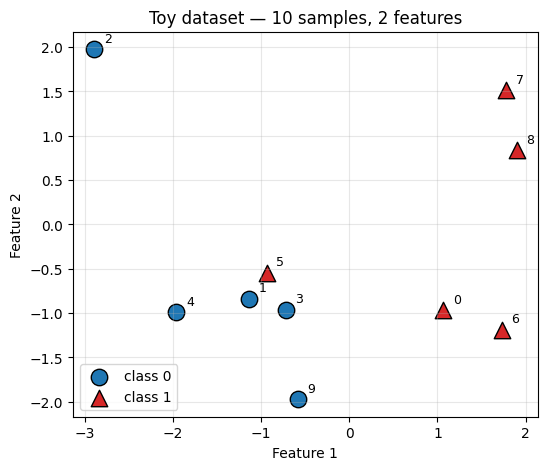

In [3]:
X_np, y_np = X_toy.numpy(), y_toy.numpy()

plt.figure(figsize=(6, 5))
for cls, color, marker in [(0, 'tab:blue', 'o'), (1, 'tab:red', '^')]:
    pts = X_np[y_np == cls]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker,
                s=140, edgecolors='k', label=f'class {cls}')

# Label each point with its dataset index, so it ties back to dataset[i]
for i, (f1, f2) in enumerate(X_np):
    plt.annotate(str(i), (f1, f2), textcoords='offset points', xytext=(7, 5), fontsize=9)

plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Toy dataset — 10 samples, 2 features')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 3. Writing a `Dataset`

Exactly three methods. There is no fourth.

- **`__init__`** — stores whatever is needed to *locate* a sample. It does **not** have to load the data; for images you would store filenames and read each file only when asked.
- **`__len__`** — returns an integer. The `DataLoader` uses it for the legal index range and to compute how many batches an epoch contains.
- **`__getitem__`** — takes one index, returns **one** sample. The batch dimension is added later, by the loader. Never here.

In [4]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]                      # how many samples

    def __getitem__(self, index):
        return self.features[index], self.labels[index]    # ONE (features, label) pair

In [5]:
toy_dataset = CustomDataset(X_toy, y_toy)

print('len(toy_dataset)  ->', len(toy_dataset))            # calls __len__
print('toy_dataset[2]    ->', toy_dataset[2])              # calls __getitem__
print()

features, label = toy_dataset[2]
print('features shape    ->', features.shape, ' <- no batch dimension')
print('label shape       ->', label.shape, '   <- a scalar tensor')
print('returned type     ->', type(toy_dataset[2]).__name__, 'of 2 tensors')

len(toy_dataset)  -> 10
toy_dataset[2]    -> (tensor([-2.8954,  1.9769]), tensor(0))

features shape    -> torch.Size([2])  <- no batch dimension
label shape       -> torch.Size([])    <- a scalar tensor
returned type     -> tuple of 2 tensors


Neither `len()` nor `[2]` is a special PyTorch power — they are **ordinary Python protocols**. `len(obj)` dispatches to `obj.__len__()`, and `obj[i]` dispatches to `obj.__getitem__(i)`. That is exactly why the interface feels natural.

**Try it:** change the index below and confirm the output against the table in section 2.

In [6]:
for i in [0, 4, 9]:
    f, l = toy_dataset[i]
    print(f'toy_dataset[{i}] -> features {f.tolist()}, label {l.item()}')

toy_dataset[0] -> features [1.0683389902114868, -0.9700734615325928], label 1
toy_dataset[4] -> features [-1.962874412536621, -0.9922513365745544], label 0
toy_dataset[9] -> features [-0.5872306227684021, -1.9717174768447876], label 0


## 4. Wiring the `DataLoader`

One line. You write no batching code at all.

In [7]:
toy_loader = DataLoader(toy_dataset, batch_size=2, shuffle=False)

print('number of batches:', len(toy_loader))
print()
for i, (batch_features, batch_labels) in enumerate(toy_loader):
    print(f'batch {i + 1}: {batch_features.tolist()} -> {batch_labels.tolist()}')

number of batches: 5

batch 1: [[1.0683389902114868, -0.9700734615325928], [-1.1402153968811035, -0.8387923240661621]] -> [1, 0]
batch 2: [[-2.895397186279297, 1.9768623113632202], [-0.7206343412399292, -0.96059250831604]] -> [0, 0]
batch 3: [[-1.962874412536621, -0.9922513365745544], [-0.9382051229476929, -0.5430481433868408]] -> [0, 1]
batch 4: [[1.7272592782974243, -1.1858267784118652], [1.7773665189743042, 1.5115759372711182]] -> [1, 1]
batch 5: [[1.8996925354003906, 0.8344448208808899], [-0.5872306227684021, -1.9717174768447876]] -> [1, 0]


With `shuffle=False` the batches are indices `[0,1]`, `[2,3]`, `[4,5]`, `[6,7]`, `[8,9]` — check them against the table in section 2 and every value matches.

### Where the batch dimension comes from

This is the single most common source of shape confusion, so watch it happen:

Two things to take from that:

- `len(loader)` is `ceil(n / batch_size)` when `drop_last=False`, and `floor(n / batch_size)` when it is `True`.
- `drop_last=True` means the model **never sees** the samples in the incomplete final batch that epoch. On 10 samples that is a real loss; on 50,000 it is negligible.

The extremes are the named regimes you already know:

| `batch_size` | Batches/epoch | Updates/epoch | Regime |
|---|---|---|---|
| `10` (all) | 1 | 1 | batch gradient descent |
| `3` | 4 | 4 | mini-batch gradient descent |
| `1` | 10 | 10 | stochastic gradient descent |

They are not three algorithms. **One algorithm, one knob.**

## 6. What `shuffle=True` actually does

`shuffle` is not a formatting option — it selects a **sampler**:

- `shuffle=False` → `SequentialSampler`: indices in order, `0, 1, 2, …`
- `shuffle=True` → `RandomSampler`: a **fresh permutation every epoch**, sampled *without* replacement, so every sample still appears exactly once per epoch.

Run this to see the permutation change between epochs:

In [9]:
shuffled_loader = DataLoader(toy_dataset, batch_size=3, shuffle=True)

for epoch in range(3):
    order = [lbl.tolist() for _, lbl in shuffled_loader]
    print(f'epoch {epoch + 1}: label batches -> {order}')

print()
print('Different composition every epoch — but always 10 samples, each exactly once.')

epoch 1: label batches -> [[0, 1, 0], [0, 1, 1], [0, 1, 0], [1]]
epoch 2: label batches -> [[1, 0, 0], [1, 0, 1], [1, 0, 0], [1]]
epoch 3: label batches -> [[0, 0, 1], [0, 0, 1], [1, 0, 1], [1]]

Different composition every epoch — but always 10 samples, each exactly once.


**What to remember:**
- A `Dataset` answers *"how many?"* and *"give me sample i"*. Nothing else.
- A `DataLoader` turns that into shuffled, batched tensors. You write no batching code.
- `__getitem__` returns **one** sample. The batch dimension is created by collate.
- The same two classes serve 10 rows and 10 million rows without modification.

### Check yourself

1. A `DataLoader` produced batches of 2 with no batching code from you. Which two `CustomDataset` methods did it call, and what does each return?
2. 250 samples, `batch_size=32`, `drop_last=False`. How many batches, and what size is the last one?
3. Where is the batch dimension created — `__init__`, `__getitem__`, or the collate step?
4. Why do evaluation loaders use `shuffle=False`?


